# 05. Regime-Specific Portfolio Construction

In the previous notebook, a Hidden Markov Model was used to identify latent market regimes from SPY returns and rolling volatility. The model classified the market into three persistent states interpreted as **Bull**, **Neutral**, and **Crisis** regimes.

This notebook uses those regime labels to estimate **regime-specific return and covariance structures** for the full multi-asset portfolio universe. The key idea is that asset behavior may differ substantially across market environments, so a single full-sample covariance matrix may not adequately represent the risk structure faced by investors over time.

More formally, instead of assuming that returns always follow one common distribution,

$$
r_t \sim \mathcal{N}(\mu, \Sigma),
$$

we now allow the return distribution to depend on the market regime $S_t$:

$$
r_t \mid S_t = k \sim \mathcal{N}(\mu_k, \Sigma_k),
$$

where each regime $k$ has its own mean return vector $\mu_k$ and covariance matrix $\Sigma_k$.

The purpose of this notebook is therefore to:

1. merge the multi-asset return data with the detected market regimes,
2. estimate regime-specific mean returns and covariance matrices,
3. visualize how asset relationships differ across regimes, and
4. construct minimum variance and maximum Sharpe portfolios for each market regime.

This notebook extends the static mean-variance framework from Notebook 3 into a regime-aware setting and prepares the portfolio inputs that will later be used in the dynamic backtesting stage of the project.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Load multi-asset returns and regime labels
returns = pd.read_csv(
    "../data/processed/asset_returns.csv",
    index_col=0,
    parse_dates=True
)

market_regimes = pd.read_csv(
    results_dir / "market_regimes.csv",
    index_col=0,
    parse_dates=True
)

returns.head(), market_regimes.head()

(                 EFA       GLD       SPY       TLT       VNQ
 Date                                                        
 2010-01-05  0.000881 -0.000911  0.002644  0.006438 -0.001123
 2010-01-06  0.004218  0.016365  0.000704 -0.013477 -0.001800
 2010-01-07 -0.003866 -0.006207  0.004212  0.001680  0.010749
 2010-01-08  0.007891  0.004951  0.003322 -0.000447 -0.007377
 2010-01-11  0.008176  0.013201  0.001396 -0.005503  0.005817,
             regime regime_label
 Date                           
 2010-02-02       2      Neutral
 2010-02-03       2      Neutral
 2010-02-04       2      Neutral
 2010-02-05       2      Neutral
 2010-02-08       2      Neutral)

In [2]:
# Merge returns with regime labels

regime_returns = returns.join(market_regimes, how="inner")

regime_returns.head()

,EFA,GLD,SPY,TLT,VNQ,regime,regime_label
Date,,,,,,,
2010-02-02,0.016517,0.007173,0.012031,0.002849,0.013615,2,Neutral
2010-02-03,-0.010547,-0.003948,-0.004995,-0.011664,-0.016407,2,Neutral
2010-02-04,-0.041590,-0.040649,-0.031352,0.015703,-0.037749,2,Neutral
2010-02-05,-0.001747,0.002966,0.002064,0.002178,0.018221,2,Neutral
2010-02-08,-0.020012,-0.006133,-0.007245,0.001303,-0.022100,2,Neutral


## Exploratory Regime Breakdown

Before estimating regime-specific means and covariance matrices, it is useful to examine how the return data are distributed across the detected market regimes. In particular, three questions matter:

1. How many observations are available in each regime?
2. Over what time periods do those regimes occur?
3. Do average asset returns appear to differ meaningfully across regimes?

These checks help assess whether each regime contains enough data for reliable estimation and provide an initial sense of how asset behavior changes across market environments.

In [4]:
# Regime counts and date ranges

regime_overview = regime_returns.groupby("regime_label").agg(
    observations=("regime_label", "size"),
    start_date=("regime_label", lambda x: x.index.min()),
    end_date=("regime_label", lambda x: x.index.max())
)

regime_overview = regime_overview.sort_values("observations", ascending=False)

regime_overview

,observations,start_date,end_date
regime_label,,,
Bull,2772,2010-03-02,2026-03-09
Neutral,1184,2010-02-02,2025-05-28
Crisis,93,2011-08-08,2025-05-07


The regime distribution follows a typical pattern observed in financial markets. The **Bull regime dominates the sample**, while the **Neutral regime occurs less frequently**, and the **Crisis regime appears only during relatively short periods of market stress**. This imbalance is expected, as financial markets tend to spend long periods in stable environments while severe disruptions occur less often but have large economic impact.

In [5]:
# Average daily returns by regime

assets = ["SPY", "EFA", "GLD", "TLT", "VNQ"]

avg_returns_by_regime = regime_returns.groupby("regime_label")[assets].mean()

avg_returns_by_regime

,SPY,EFA,GLD,TLT,VNQ
regime_label,,,,,
Bull,0.000861,0.000518,0.000273,-0.000004,0.000510
Crisis,-0.000851,-0.001827,0.002836,0.001619,-0.001778
Neutral,-0.000163,-0.000143,0.000383,0.000250,0.000132


The regime-specific average returns show clear differences in asset performance across market environments. In the **Bull regime**, equity assets such as SPY, EFA, and VNQ generate positive returns, consistent with strong market conditions. In the **Neutral regime**, returns are generally weaker and closer to zero. In the **Crisis regime**, equity assets exhibit negative returns while defensive assets such as GLD and TLT perform relatively well, reflecting their role as safe-haven assets during market stress.

In [6]:
# Annualized average returns by regime

annualized_avg_returns_by_regime = avg_returns_by_regime * 252

annualized_avg_returns_by_regime

,SPY,EFA,GLD,TLT,VNQ
regime_label,,,,,
Bull,0.216964,0.130499,0.068708,-0.000892,0.128640
Crisis,-0.214499,-0.460432,0.714756,0.408082,-0.448092
Neutral,-0.040964,-0.036143,0.096451,0.063110,0.033138


Annualizing the returns further shows the economic magnitude of these differences. Equities perform strongly in the **Bull regime**, while defensive assets such as gold and long-term Treasuries show stronger performance during **Crisis regimes**. Although the crisis estimates should be interpreted cautiously due to the smaller number of observations, the overall patterns align with well-known market behavior during periods of financial stress.

## Regime-Specific Mean Returns and Covariance Matrices

The next step is to formally estimate the regime-dependent parameters needed for portfolio optimization.

For each market regime $k$, we estimate:

- a mean return vector $\mu_k$
- a covariance matrix $\Sigma_k$

This allows the return distribution to depend on the current regime.

These regime-specific estimates will later be used to construct minimum variance and maximum Sharpe portfolios for each market environment.

In [7]:
# Estimate regime-specific mean returns

assets = ["SPY", "EFA", "GLD", "TLT", "VNQ"]

regime_mean_returns = regime_returns.groupby("regime_label")[assets].mean()

regime_mean_returns

,SPY,EFA,GLD,TLT,VNQ
regime_label,,,,,
Bull,0.000861,0.000518,0.000273,-0.000004,0.000510
Crisis,-0.000851,-0.001827,0.002836,0.001619,-0.001778
Neutral,-0.000163,-0.000143,0.000383,0.000250,0.000132


In [8]:
# Annualize regime mean returns

regime_mean_returns_annual = regime_mean_returns * 252

regime_mean_returns_annual

,SPY,EFA,GLD,TLT,VNQ
regime_label,,,,,
Bull,0.216964,0.130499,0.068708,-0.000892,0.128640
Crisis,-0.214499,-0.460432,0.714756,0.408082,-0.448092
Neutral,-0.040964,-0.036143,0.096451,0.063110,0.033138


This give us
- μ_bull
- μ_neutral
- μ_crisis

in annualized form.

In [9]:
# Estimate regime covariance matrices

regime_covariances = {}

for regime in regime_returns["regime_label"].unique():
    
    regime_data = regime_returns[regime_returns["regime_label"] == regime]
    
    cov_matrix = regime_data[assets].cov()
    
    regime_covariances[regime] = cov_matrix

regime_covariances["Bull"]

,SPY,EFA,GLD,TLT,VNQ
SPY,0.000043,0.000042,0.000005,-0.000010,0.000031
EFA,0.000042,0.000066,0.000016,-0.000009,0.000035
GLD,0.000005,0.000016,0.000096,0.000016,0.000013
TLT,-0.000010,-0.000009,0.000016,0.000065,0.000013
VNQ,0.000031,0.000035,0.000013,0.000013,0.000080


This stores covariance matrices: 
- Σ_bull
- Σ_neutral
- Σ_crisis

In [10]:
# Annualize covariance matrices

regime_covariances_annual = {}

for regime, cov in regime_covariances.items():
    
    regime_covariances_annual[regime] = cov * 252

regime_covariances_annual["Bull"]

,SPY,EFA,GLD,TLT,VNQ
SPY,0.010951,0.010530,0.001179,-0.002543,0.007932
EFA,0.010530,0.016515,0.003921,-0.002377,0.008736
GLD,0.001179,0.003921,0.024130,0.004102,0.003293
TLT,-0.002543,-0.002377,0.004102,0.016431,0.003183
VNQ,0.007932,0.008736,0.003293,0.003183,0.020108


The covariance matrices above describe how asset returns co-move within each market regime. Because asset correlations often increase during periods of market stress, the covariance structure may differ substantially across regimes.

To better visualize these differences, we can convert the covariance matrices into correlation matrices and displays them using heatmaps. This makes it easier to observe how relationships between assets change across market environments.

## Correlation Structure Across Market Regimes

In financial markets, correlations between risky assets often increase during periods of market stress, reducing the benefits of diversification. Visualizing correlation matrices across regimes therefore provides insight into how diversification opportunities change across market environments.

In [12]:
# Compute regime-specific correlation matrices

regime_correlations = {}

for regime, cov in regime_covariances.items():
    
    std = np.sqrt(np.diag(cov))
    
    corr = cov / np.outer(std, std)
    
    corr = pd.DataFrame(corr, index=cov.index, columns=cov.columns)
    
    regime_correlations[regime] = corr

regime_correlations["Bull"]

,SPY,EFA,GLD,TLT,VNQ
SPY,1.000000,0.783033,0.072553,-0.189540,0.534556
EFA,0.783033,1.000000,0.196399,-0.144273,0.479399
GLD,0.072553,0.196399,1.000000,0.206028,0.149482
TLT,-0.189540,-0.144273,0.206028,1.000000,0.175086
VNQ,0.534556,0.479399,0.149482,0.175086,1.000000


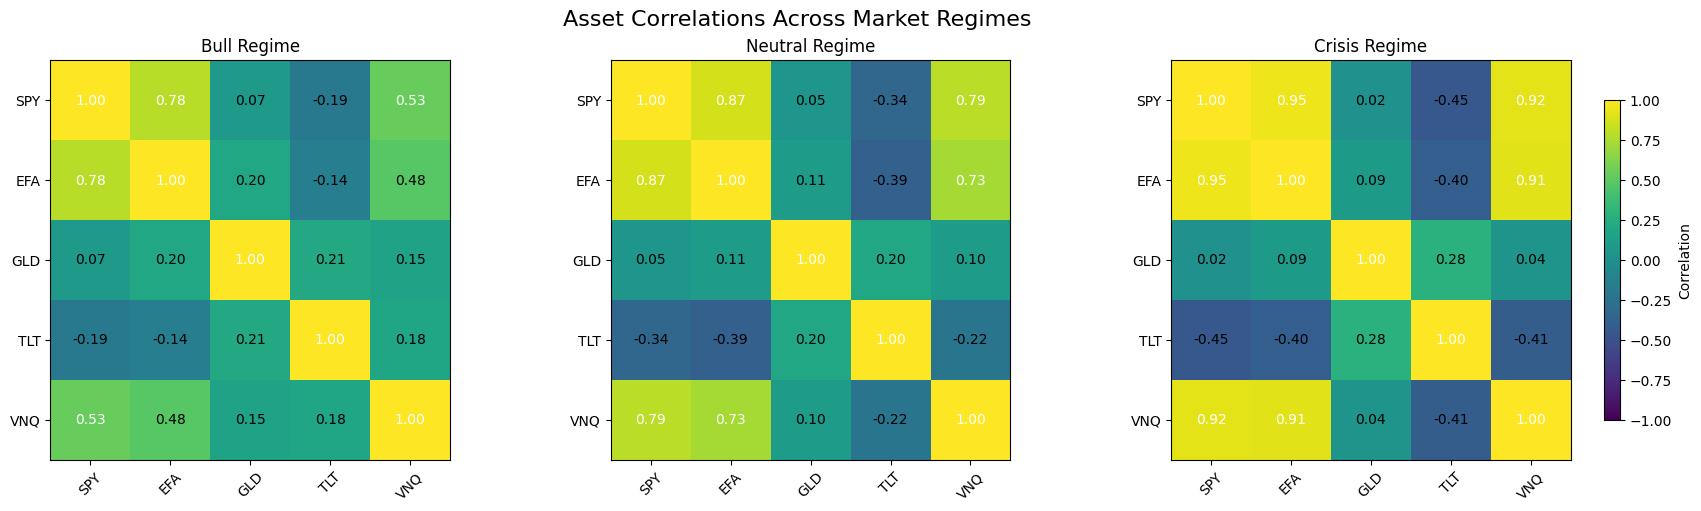

In [16]:
# Plot correlation heatmaps for each regime

regime_order = ["Bull", "Neutral", "Crisis"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, regime in zip(axes, regime_order):
    corr = regime_correlations[regime]

    im = ax.imshow(corr, vmin=-1, vmax=1)

    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45)

    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)

    ax.set_title(f"{regime} Regime")

    # add correlation values inside cells
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            value = corr.iloc[i, j]
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(value) > 0.5 else "black"
            )

# single colorbar placed outside all subplots
cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("Correlation")

fig.suptitle("Asset Correlations Across Market Regimes", fontsize=16)

plt.show()

The correlation heatmaps show that asset relationships differ meaningfully across market regimes. In the **Bull regime**, correlations among risky assets are positive but more moderate, allowing greater diversification benefits. In the **Crisis regime**, correlations between equity-oriented assets such as SPY, EFA, and VNQ increase sharply, indicating that risky assets tend to move together during periods of market stress. At the same time, TLT remains negatively correlated with equities, reinforcing its role as a defensive asset. These differences support the use of regime-specific covariance matrices in portfolio construction.

## Regime-Specific Portfolio Optimization

With regime-specific mean return vectors and covariance matrices estimated, the next step is to construct optimal portfolios for each market environment.

For each regime, two portfolios are computed:

- the **minimum variance portfolio**, which minimizes portfolio volatility
- the **maximum Sharpe portfolio**, which maximizes risk-adjusted return

This extends the static mean-variance framework from Notebook 3 by allowing the portfolio inputs to vary across Bull, Neutral, and Crisis regimes. If asset return and covariance structures differ meaningfully across regimes, the optimal portfolio weights should differ as well.

In [17]:
# Portfolio optimization helpers

risk_free_rate = 0.036

def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def portfolio_performance(weights, mean_returns, cov_matrix):
    port_return = portfolio_return(weights, mean_returns)
    port_vol = portfolio_volatility(weights, cov_matrix)
    return port_return, port_vol

In [18]:
# Optimize portfolios within each regime

n_portfolios = 50000
random_seed = 42
np.random.seed(random_seed)

regime_portfolio_results = {}

for regime in ["Bull", "Neutral", "Crisis"]:
    
    mean_returns = regime_mean_returns_annual.loc[regime].values
    cov_matrix = regime_covariances_annual[regime].values
    
    sim_returns = []
    sim_volatility = []
    sim_weights = []
    sharpe_ratios = []
    
    for _ in range(n_portfolios):
        weights = np.random.random(len(assets))
        weights /= np.sum(weights)
        
        port_return, port_vol = portfolio_performance(weights, mean_returns, cov_matrix)
        sharpe = (port_return - risk_free_rate) / port_vol
        
        sim_returns.append(port_return)
        sim_volatility.append(port_vol)
        sim_weights.append(weights)
        sharpe_ratios.append(sharpe)
    
    sim_returns = np.array(sim_returns)
    sim_volatility = np.array(sim_volatility)
    sim_weights = np.array(sim_weights)
    sharpe_ratios = np.array(sharpe_ratios)
    
    min_vol_idx = np.argmin(sim_volatility)
    max_sharpe_idx = np.argmax(sharpe_ratios)
    
    regime_portfolio_results[regime] = {
        "sim_returns": sim_returns,
        "sim_volatility": sim_volatility,
        "sim_weights": sim_weights,
        "sharpe_ratios": sharpe_ratios,
        "min_vol_idx": min_vol_idx,
        "max_sharpe_idx": max_sharpe_idx,
        "min_vol_weights": sim_weights[min_vol_idx],
        "max_sharpe_weights": sim_weights[max_sharpe_idx],
        "min_vol_return": sim_returns[min_vol_idx],
        "min_vol_volatility": sim_volatility[min_vol_idx],
        "max_sharpe_return": sim_returns[max_sharpe_idx],
        "max_sharpe_volatility": sim_volatility[max_sharpe_idx],
        "max_sharpe_ratio": sharpe_ratios[max_sharpe_idx]
    }

In [19]:
# Summary of regime-specific optimal portfolios

regime_portfolio_summary = pd.DataFrame({
    "Regime": ["Bull", "Neutral", "Crisis"],
    "Min_Vol_Return": [regime_portfolio_results[r]["min_vol_return"] for r in ["Bull", "Neutral", "Crisis"]],
    "Min_Vol_Volatility": [regime_portfolio_results[r]["min_vol_volatility"] for r in ["Bull", "Neutral", "Crisis"]],
    "Max_Sharpe_Return": [regime_portfolio_results[r]["max_sharpe_return"] for r in ["Bull", "Neutral", "Crisis"]],
    "Max_Sharpe_Volatility": [regime_portfolio_results[r]["max_sharpe_volatility"] for r in ["Bull", "Neutral", "Crisis"]],
    "Max_Sharpe_Ratio": [regime_portfolio_results[r]["max_sharpe_ratio"] for r in ["Bull", "Neutral", "Crisis"]],
})

regime_portfolio_summary

,Regime,Min_Vol_Return,Min_Vol_Volatility,Max_Sharpe_Return,Max_Sharpe_Volatility,Max_Sharpe_Ratio
0,Bull,0.123371,0.070944,0.187055,0.088832,1.700454
1,Neutral,0.038359,0.099497,0.083388,0.134235,0.353021
2,Crisis,0.309579,0.209223,0.552203,0.243449,2.120374


### Portfolio Allocation by Regime

The table above summarizes the performance characteristics of the optimal portfolios identified within each market regime. Because each regime has its own expected return vector and covariance structure, the portfolios that minimize volatility or maximize the Sharpe ratio differ across regimes.

One notable result is the relatively high estimated return and Sharpe ratio in the Crisis regime. This is largely driven by the strong performance of defensive assets such as **gold (GLD)** and **long-term Treasuries (TLT)** during periods of market stress. Because the crisis regime contains relatively few observations, annualizing the average returns from these periods can produce unusually large estimates. These values should therefore be interpreted cautiously and primarily as a reflection of the extreme market movements that characterize crisis environments.

To better understand how the optimizer is responding to these regime-specific return and covariance structures, the following tables display the **asset allocations** for both the **minimum variance** and **maximum Sharpe** portfolios in each regime.

In [22]:
# Inspect regime-specific portfolio weights

min_vol_weights_df = pd.DataFrame({
    regime: regime_portfolio_results[regime]["min_vol_weights"]
    for regime in ["Bull", "Neutral", "Crisis"]
}, index=assets)

max_sharpe_weights_df = pd.DataFrame({
    regime: regime_portfolio_results[regime]["max_sharpe_weights"]
    for regime in ["Bull", "Neutral", "Crisis"]
}, index=assets)

print("Minimum Variance Portfolio Weights")
display(min_vol_weights_df.round(4))

print("\nMaximum Sharpe Portfolio Weights")
display(max_sharpe_weights_df.round(4))

Minimum Variance Portfolio Weights


,Bull,Neutral,Crisis
SPY,0.5170,0.1478,0.1783
EFA,0.0174,0.1608,0.0679
GLD,0.1033,0.2168,0.2747
TLT,0.3456,0.4534,0.4641
VNQ,0.0167,0.0212,0.0150



Maximum Sharpe Portfolio Weights


,Bull,Neutral,Crisis
SPY,0.8411,0.0192,0.0708
EFA,0.0057,0.0073,0.0034
GLD,0.0314,0.7363,0.6497
TLT,0.1081,0.1855,0.2667
VNQ,0.0137,0.0517,0.0094


The regime-specific portfolio weights show clear shifts in optimal allocations across market environments. In the Bull regime, the maximum Sharpe portfolio allocates heavily to equities, particularly SPY, reflecting strong risk asset performance during stable market conditions. In the Neutral regime, the portfolio shifts toward defensive assets, with gold and Treasuries receiving the largest weights. During Crisis regimes, the optimal portfolio becomes highly defensive, concentrating primarily in gold and long-term Treasuries while allocating very little to equities.

---

To better visualize how the optimal portfolio changes across market environments, the asset allocations of the **maximum Sharpe portfolios** are shown below for each regime.

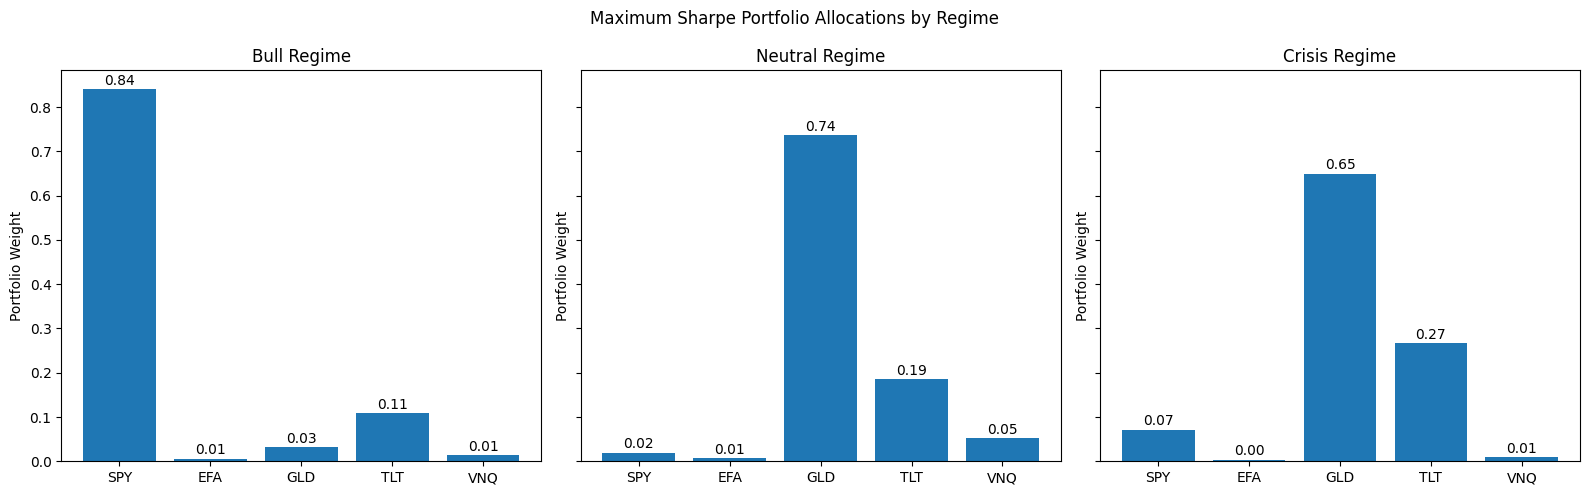

In [23]:
regimes = ["Bull", "Neutral", "Crisis"]

fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)

for ax, regime in zip(axes, regimes):

    weights = regime_portfolio_results[regime]["max_sharpe_weights"]

    ax.bar(assets, weights)

    ax.set_title(f"{regime} Regime")
    ax.set_ylabel("Portfolio Weight")

    for i, w in enumerate(weights):
        ax.text(i, w + 0.01, f"{w:.2f}", ha="center")

plt.suptitle("Maximum Sharpe Portfolio Allocations by Regime")

plt.tight_layout()

plt.show()

### Interpretation

In the **Bull regime**, the portfolio is dominated by **SPY**, reflecting strong equity returns and relatively favorable risk-adjusted performance during stable market conditions. A smaller allocation to **TLT** remains because Treasuries still provide diversification benefits.

In the **Neutral regime**, the optimizer shifts heavily toward **GLD** and **TLT**. This occurs because equity returns are weak or slightly negative in this regime, while gold has the highest estimated return and relatively low correlations with the other assets, making it especially attractive for Sharpe-ratio optimization.

In the **Crisis regime**, the portfolio becomes highly defensive, with most of the weight allocated to **GLD** and **TLT** and very little allocated to equities. This is consistent with the regime-specific return estimates, where risky assets perform poorly and safe-haven assets perform relatively well during market stress.

In [25]:
# Save regime-specific portfolio outputs

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Save annualized regime mean returns
regime_mean_returns_annual.to_csv(results_dir / "regime_mean_returns.csv")

# Save annualized covariance matrices
for regime, cov in regime_covariances_annual.items():
    cov.to_csv(results_dir / f"covariance_{regime.lower()}.csv")

# Save minimum variance weights
min_vol_weights_df.to_csv(results_dir / "regime_min_variance_weights.csv")

# Save maximum Sharpe weights
max_sharpe_weights_df.to_csv(results_dir / "regime_max_sharpe_weights.csv")

# Save summary table
regime_portfolio_summary.to_csv(results_dir / "regime_portfolio_summary.csv", index=False)

# Save metadata
regime_portfolio_metadata = {
    "risk_free_rate": risk_free_rate,
    "n_portfolios": n_portfolios,
    "random_seed": random_seed,
    "assets": assets,
    "regimes": ["Bull", "Neutral", "Crisis"],
    "optimization_method": "Monte Carlo simulation"
}

with open(results_dir / "regime_portfolio_metadata.json", "w") as f:
    json.dump(regime_portfolio_metadata, f, indent=4)

## Summary and Next Steps

This notebook extended the portfolio optimization framework by allowing expected returns and covariance matrices to vary across market regimes. Using the Hidden Markov Model classifications from Notebook 4, separate mean return vectors and covariance matrices were estimated for Bull, Neutral, and Crisis market environments, and regime-specific minimum variance and maximum Sharpe portfolios were constructed.

The results show that optimal allocations differ meaningfully across regimes. In Bull markets, the maximum Sharpe portfolio tilts heavily toward equities, while in Neutral and Crisis regimes the optimizer shifts toward more defensive assets such as gold and long-term Treasuries. This regime dependence provides a strong justification for moving beyond static portfolio optimization and toward a dynamic allocation framework.